# Ajuste de un modelo LLM para una tarea de clasificación de opiniones

## 1) Elegimos un conjunto de datos de opiniones de HuggingFace.


In [ ]:
from datasets import load_dataset_builder

In [ ]:
#Seleccionamos el dataset

ds_builder = load_dataset_builder("FJC/corpusELE.csv")

print("Descripción del dataset:", ds_builder.info.description)
print("Características (features) del dataset:", ds_builder.info.features)


Repo card metadata block was not found. Setting CardData to empty.


Descripción del dataset: 
Características (features) del dataset: {'Unnamed: 0': Value('int64'), 'numero': Value('float64'), 'nivel': Value('string'), 'lenguaM': Value('string'), 'pClave': Value('string'), 'frase': Value('string'), 'archivo': Value('string')}


In [ ]:
from datasets import get_dataset_split_names

get_dataset_split_names("FJC/corpusELE.csv")


Repo card metadata block was not found. Setting CardData to empty.


['train']

El conjunto de datos tiene un solo subconjuntos: train.

## 2) Cargamos este conjunto con la librería de datasets.

In [ ]:
#Descargamos el dataset

from datasets import load_dataset

dataset = load_dataset("FJC/corpusELE.csv")
dataset

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'numero', 'nivel', 'lenguaM', 'pClave', 'frase', 'archivo'],
        num_rows: 46787
    })
})

In [ ]:
#Observamos las categorías:

LABELS = dataset['train'].unique('nivel')
NUM_LABELS = len(LABELS)
print('LABELS:', LABELS, 'num_labels:', NUM_LABELS )

LABELS: ['A1', 'B2', 'A2', 'B1', 'C1'] num_labels: 5


In [ ]:
#Contamos cuántos ejemplos hay de cada categoría

class_counts = dataset['train'].to_pandas()['nivel'].value_counts()
print(class_counts)

nivel
A2    13926
A1    12284
B1    10848
B2     6601
C1     3128
Name: count, dtype: int64


## 3) Fine-tuning de un modelo pre-entrenado.
### Ajustamos el modelo base para la tarea de clasificación de opiniones.

El modelo elegido ha sido MrBert en español.


###  1.  Tokenización

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("BSC-LT/MrBERT-es")

In [ ]:
#Vemos cúal es el número máximo de tokens de nuestro dataset

MAX_LENGTH= max([len(tokenizer(text).input_ids) for text in dataset['train']['frase']])
print("Tamaño máximo", MAX_LENGTH)

Tamaño máximo 103


In [ ]:
#Tokenizamos por lotes:

def tokenize(examples):
    return tokenizer(examples["frase"], padding="max_length",max_length=MAX_LENGTH)

In [ ]:
#Aplicamos la función anterior a todos los splits:

encoded_data = dataset.map(tokenize, batched=True)
encoded_data

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'numero', 'nivel', 'lenguaM', 'pClave', 'frase', 'archivo', 'input_ids', 'attention_mask'],
        num_rows: 46787
    })
})

In [ ]:
#Comprobamos que todos los textos tienen el mismo tamaño

import random
for i in range(10):
    index = random.randint(0,encoded_data['train'].num_rows)
    print('frase:', index, ' len:', len(encoded_data['train'][index]['input_ids']), 'nivel: ', encoded_data['train'][index]['nivel'])

frase: 41905  len: 103 nivel:  B1
frase: 7296  len: 103 nivel:  B2
frase: 1639  len: 103 nivel:  A1
frase: 18024  len: 103 nivel:  B1
frase: 16049  len: 103 nivel:  B1
frase: 14628  len: 103 nivel:  A1
frase: 9144  len: 103 nivel:  A2
frase: 6717  len: 103 nivel:  A1
frase: 44348  len: 103 nivel:  B2
frase: 35741  len: 103 nivel:  A2


In [ ]:
# Creamos los mapeos de etiquetas a IDs y viceversa
id2label = {idx: label for idx, label in enumerate(LABELS)}
label2id = {label: idx for idx, label in enumerate(LABELS)}

# Re-tokenize the dataset to ensure 'nivel' and 'frase' are present
encoded_data = dataset.map(tokenize, batched=True)

# Función para mapear las etiquetas y renombrar la columna
def map_labels_and_rename(example):
    example['labels'] = label2id[example['nivel']]
    return example

# Aplicamos la función a todo el dataset
encoded_data = encoded_data.map(map_labels_and_rename, batched=False)

# Renombramos la columna 'frase' a 'text'
encoded_data = encoded_data.rename_column("frase", "text")

# Eliminamos la columna original 'nivel' si ya no es necesaria y otras columnas no utilizadas por el modelo
encoded_data = encoded_data.remove_columns(['nivel', 'Unnamed: 0', 'numero', 'lenguaM', 'pClave', 'archivo'])

# Verificamos las nuevas características del dataset
print(encoded_data['train'].features)
print(encoded_data['train'][0])

Map:   0%|          | 0/46787 [00:00<?, ? examples/s]

{'text': Value('string'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8')), 'labels': Value('int64')}
{'text': 'mi familia es solo 3 persona , me madre y me hermano y mi .', 'input_ids': [0, 2194, 4636, 1451, 2822, 51077, 51139, 3855, 2884, 1618, 7045, 1431, 1618, 13119, 1431, 2194, 2393, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'labels': 0}


In [ ]:
# Dividimos el conjunto de entrenamiento en entrenamiento y validación
train_validation_split = encoded_data['train'].train_test_split(test_size=0.1, seed=42)

print(f"Tamaño del conjunto de entrenamiento: {train_validation_split['train'].num_rows}")
print(f"Tamaño del conjunto de validación: {train_validation_split['test'].num_rows}")

Tamaño del conjunto de entrenamiento: 42108
Tamaño del conjunto de validación: 4679


In [ ]:
import os

# Definir las rutas de guardado en Google Drive
drive_path = '/content/drive/MyDrive/ColabNotebooks/APLICACIONES/ALBERTO/'
train_output_file = os.path.join(drive_path, 'train_dataset_corpusELE_file.csv')
val_output_file = os.path.join(drive_path, 'validation_dataset_corpusELE_file.csv')

# Convertir los datasets de HuggingFace a pandas DataFrames y guardar como CSV
# Asegurarse de que las columnas 'input_ids' y 'attention_mask' sean manejadas correctamente si no se desean en el CSV, o convertirlas a string
# Para simplicidad, vamos a seleccionar las columnas que son más fácilmente representables en CSV.

# Para el dataset de entrenamiento
train_df = train_validation_split['train'].to_pandas()
train_df.to_csv(train_output_file, index=False)

# Para el dataset de validación
val_df = train_validation_split['test'].to_pandas()
val_df.to_csv(val_output_file, index=False)

print(f"Conjunto de entrenamiento guardado en: {train_output_file}")
print(f"Conjunto de validación guardado en: {val_output_file}")

Conjunto de entrenamiento guardado en: /content/drive/MyDrive/ColabNotebooks/APLICACIONES/ALBERTO/train_dataset_corpusELE_file.csv
Conjunto de validación guardado en: /content/drive/MyDrive/ColabNotebooks/APLICACIONES/ALBERTO/validation_dataset_corpusELE_file.csv


### 2. Cargamos el modelo y ajustamos los parámetros y las métricas de evaluación.

In [ ]:
#Cargamos el modelo:

from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained("BSC-LT/MrBERT-es", num_labels=NUM_LABELS)

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: BSC-LT/MrBERT-es
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#Ajustamos los parámetros:

from transformers import TrainingArguments
args = TrainingArguments(output_dir="./outputs", label_names=['labels'])
args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=False,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.NO,
eval_use_gather_object=False,

In [ ]:
#Modificamos el tamaño del lote para entrenamiento y validación:

args.per_device_train_batch_size = 32
args.per_device_eval_batch_size = 32

In [ ]:
#Indicamos que la estrategia de entrenamiento para el modelo son epochs:

args.evaluation_strategy="epoch"
args.report_to='tensorboard'

In [ ]:
#Definimos las métricas para evaluar el modelo

import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


def compute_metrics(pred):

    y_true = pred.label_ids                 # son las labels reales
    y_pred = pred.predictions.argmax(-1)    # son las predicciones


    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }


### 3. Creación y re-entrenamiento del modelo

In [ ]:
# Creamos el modelo

from transformers import Trainer
trainer = Trainer(
    model = model,            # modelo que será ajustado
    train_dataset = train_validation_split['train'], # conjunto training
    eval_dataset = train_validation_split['test'],   # conjunto de validación

    args = args,     # hiperparámetros
    compute_metrics=compute_metrics    # función para computar las métricas
)

In [ ]:
print(f"Tamaño del conjunto de entrenamiento: {train_validation_split['train'].num_rows}")
print(f"Tamaño del conjunto de validación: {train_validation_split['test'].num_rows}")

Tamaño del conjunto de entrenamiento: 42108
Tamaño del conjunto de validación: 4679


In [ ]:
#y lo entrenamos

trainer.train()

Step,Training Loss
500,0.736286
1000,0.592761
1500,0.486634
2000,0.345904
2500,0.326658
3000,0.186089
3500,0.133600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3948, training_loss=0.36994962972469003, metrics={'train_runtime': 722.9581, 'train_samples_per_second': 174.732, 'train_steps_per_second': 5.461, 'total_flos': 8659803338631720.0, 'train_loss': 0.36994962972469003, 'epoch': 3.0})

### 4. Evaluación

In [ ]:
trainer.evaluate()

{'eval_loss': 0.8916938304901123,
 'eval_accuracy': 0.8020944646291943,
 'eval_f1': 0.8055808751311702,
 'eval_precision': 0.8118998249783195,
 'eval_recall': 0.7999242993885363,
 'eval_runtime': 9.3652,
 'eval_samples_per_second': 499.614,
 'eval_steps_per_second': 15.696,
 'epoch': 3.0}

### Identificación de ejemplos mal clasificados en el conjunto de validación

In [ ]:
import pandas as pd
# Obtener las predicciones del modelo para el conjunto de validación
predictions_output = trainer.predict(train_validation_split['test'])

# Las predicciones son los logits, necesitamos convertirlos a IDs de etiquetas
predicted_ids = predictions_output.predictions.argmax(axis=1)

# Obtener las etiquetas verdaderas del conjunto de validación
true_ids = predictions_output.label_ids

# Mapear los IDs de etiquetas a sus nombres originales (A1, A2, etc.)
predicted_labels_names = [id2label[id] for id in predicted_ids]
true_labels_names = [id2label[id] for id in true_ids]

# Crear un DataFrame para comparar fácilmente
comparison_df = pd.DataFrame({
    'text': train_validation_split['test']['text'],
    'true_label': true_labels_names,
    'predicted_label': predicted_labels_names
})

# Filtrar los ejemplos mal clasificados
misclassified_examples = comparison_df[comparison_df['true_label'] != comparison_df['predicted_label']]

print(f"Se encontraron {len(misclassified_examples)} ejemplos mal clasificados de un total de {len(train_validation_split['test'])} en el conjunto de validación.")

# Mostrar los primeros 10 ejemplos mal clasificados
print("\nPrimeros 10 ejemplos mal clasificados:")
display(misclassified_examples.head(10))

Se encontraron 926 ejemplos mal clasificados de un total de 4679 en el conjunto de validación.

Primeros 10 ejemplos mal clasificados:


,text,true_label,predicted_label
9,Me gustaría que me encontre otros animales en ...,A2,A1
12,"Ella siempre sabes lo que quiere , es muy deci...",A1,A2
14,querida amiga,A2,B1
22,Tengo que hacer algo más ?,B2,A2
24,He trabajado en la fotographìa .,A1,A2
36,Pero esto no faz tenemos siempre algo a encina...,A2,B2
39,"Mire , espero que le caiga mal .",B2,B1
47,"Entre otras cosas tambien dice , ¨ Yo no soy p...",C1,A2
48,"Jalid es de Arabia_Saudita , se trasladó a Din...",C1,A2
50,"De eso , ellos estan reflejando un cambio en e...",B2,C1


### Distribución de Clases Mal Clasificadas

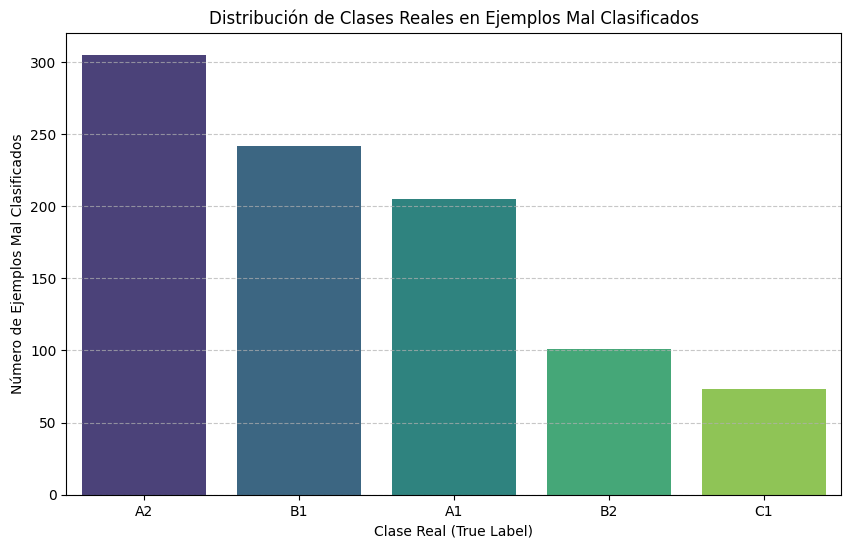

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar la ocurrencia de cada etiqueta verdadera en los ejemplos mal clasificados
misclassified_true_label_counts = misclassified_examples['true_label'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=misclassified_true_label_counts.index, y=misclassified_true_label_counts.values, hue=misclassified_true_label_counts.index, palette='viridis', legend=False)
plt.title('Distribución de Clases Reales en Ejemplos Mal Clasificados')
plt.xlabel('Clase Real (True Label)')
plt.ylabel('Número de Ejemplos Mal Clasificados')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Matriz de Confusión para Identificar Clases Confusas

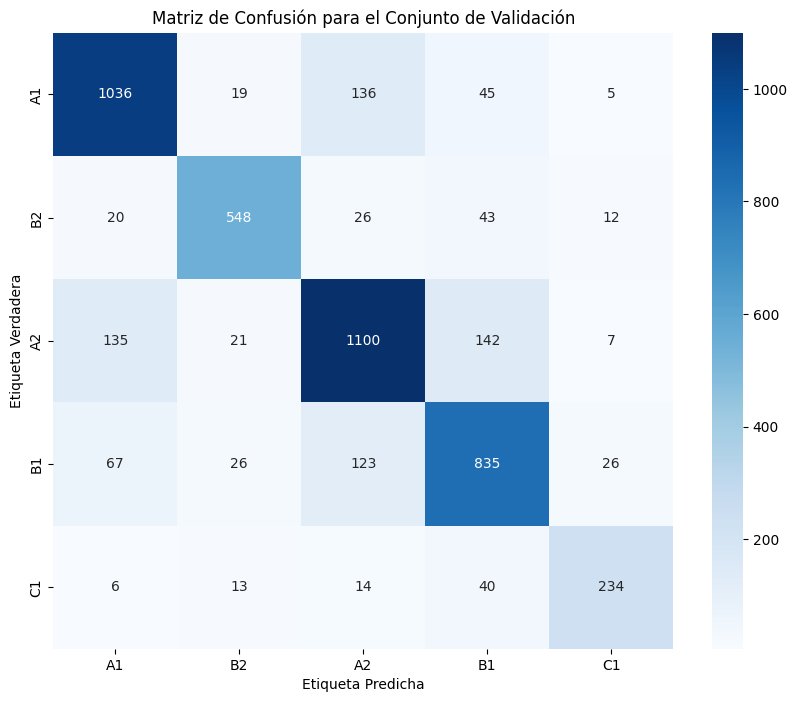

In [ ]:
from sklearn.metrics import confusion_matrix

# Calcular la matriz de confusión
cm = confusion_matrix(true_ids, predicted_ids)

# Visualizar la matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)
plt.title('Matriz de Confusión para el Conjunto de Validación')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.show()

### Porcentaje de Error por Clase

In [ ]:
import numpy as np

# Calcular el porcentaje de error por clase
error_percentages = {}
for i, label in enumerate(LABELS):
    total_true_instances = np.sum(cm[i, :])  # Suma de la fila (instancias reales de la clase i)
    correct_predictions = cm[i, i]         # Elemento de la diagonal (predicciones correctas de la clase i)
    incorrect_predictions = total_true_instances - correct_predictions

    if total_true_instances > 0:
        error_percentage = (incorrect_predictions / total_true_instances) * 100
    else:
        error_percentage = 0  # No hay instancias de esta clase en el conjunto de validación

    error_percentages[label] = error_percentage

print("Porcentaje de error por clase:")
for label, percentage in error_percentages.items():
    print(f"- Clase {label}: {percentage:.2f}%")


Porcentaje de error por clase:
- Clase A1: 16.52%
- Clase B2: 15.56%
- Clase A2: 21.71%
- Clase B1: 22.47%
- Clase C1: 23.78%


## 6) Carga del conjunto de datos de test y predicción.

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
import pandas as pd

# Ruta al archivo test.csv en Google Drive
test_file_path = '/content/drive/MyDrive/ColabNotebooks/APLICACIONES/ALBERTO/test.csv'

# Cargar el dataset de prueba
try:
    df_test = pd.read_csv(test_file_path)
    print("Dataset de test cargado correctamente:")
    display(df_test.head())
except FileNotFoundError:
    print(f"Error: El archivo '{test_file_path}' no fue encontrado. Asegúrate de que la ruta sea correcta y que Drive esté montado.")
    df_test = pd.DataFrame() # Crear un DataFrame vacío para evitar errores posteriores

In [ ]:
# Asegurarse de que el DataFrame no esté vacío antes de procesar
if not df_test.empty:
    # Preparar el DataFrame de prueba para la predicción
    # Asumimos que la columna de texto se llama 'frase' como en el dataset original
    if 'frase' in df_test.columns:
        df_test = df_test.rename(columns={'frase': 'text'})
    elif 'text' not in df_test.columns:
        print("Advertencia: La columna 'frase' o 'text' no se encontró. Asegúrate de que el CSV de prueba contenga una columna con el texto a clasificar.")
        # Intentar usar la primera columna string disponible como 'text'
        string_cols = df_test.select_dtypes(include='object').columns
        if len(string_cols) > 0:
            df_test = df_test.rename(columns={string_cols[0]: 'text'})
            print(f"Se usará la columna '{string_cols[0]}' como 'text'.")
        else:
            print("Error: No hay columnas de texto en el dataset de prueba para hacer predicciones.")
            df_test = pd.DataFrame() # Vaciar el DataFrame si no hay texto

    # Asegurarse de tener una columna 'id' para el output
    if 'id' not in df_test.columns and not df_test.empty:
        df_test['id'] = df_test.index # Usar el índice como id si no hay una columna de id
        print("Se añadió una columna 'id' basada en el índice del DataFrame.")

    # Realizar predicciones si el DataFrame no está vacío y tiene la columna 'text'
    if not df_test.empty and 'text' in df_test.columns:
        print("Realizando predicciones en el dataset de prueba...")
        # La función get_prediction espera el texto, no el DataFrame completo
        predicted_ids = [get_prediction(text) for text in df_test['text']]

        # Mapear los IDs predichos a sus etiquetas originales (A1, A2, B1, etc.)
        # 'id2label' se definió previamente en el notebook
        predicted_labels = [id2label[pred_id] for pred_id in predicted_ids]

        # Crear un DataFrame con las IDs y las etiquetas predichas
        results_df = pd.DataFrame({'id': df_test['id'], 'label': predicted_labels})

        print("Predicciones realizadas:")
        display(results_df.head())

        # Guardar los resultados en un nuevo archivo CSV en Google Drive
        output_file_path = '/content/drive/MyDrive/ColabNotebooks/APLICACIONES/ALBERTO/predictions.csv'
        results_df.to_csv(output_file_path, index=False)
        print(f"Predicciones guardadas en '{output_file_path}'")
    else:
        print("No se pudieron realizar predicciones debido a un DataFrame de prueba vacío o sin columna 'text'.")
else:
    print("El DataFrame de prueba está vacío, no se realizarán más acciones.")